In [1]:
import pandas as pd
import numpy as np
import matplotlib
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from helpers.load import *

scenario_parent_folder = Path(os.path.abspath('')) / 'logs' /  'unified' / 'buoy'

Ran with 
```
# Independent variables
independent_vars = {
    "nodeXCount" : list(np.arange(1, 26, 1)),
    "nodeYCount" : list(np.arange(1, 26, 1)),
    "nodeZCount": [1],
    "nodeZSpacing": [1],
    "nodeZOffset": list(np.arange(0, -1.8, -0.1)),
    "auvSpeed": [0],
    "propagationModel": ["underwater"],
    "waterTemperature": [20],
    "waterSalinity": [0.01],
    "stopTime": [10*60],  # seconds
    "channelWidth": [1],
    "scenarioFolderPath": ["\"unified/buoy/run\""]
}

# Dependent variables defined via lambda functions. 
# Each lambda receives a dict with the current independent variables.
dependent_vars = {
    # 1.8 because otherwise we'll have nodes out of range
    "nodeXSpacing": lambda args: 1.8 / (args["nodeXCount"] - 1) if args["nodeXCount"] > 1 else 1,
    "nodeXOffset": lambda args: -args["nodeXSpacing"] * (args["nodeXCount"] - 1) / 2,
    "nodeYSpacing": lambda args: 1.8 / (args["nodeYCount"] - 1) if args["nodeYCount"] > 1 else 1,
    "nodeYOffset": lambda args: -args["nodeYSpacing"] * (args["nodeYCount"] - 1) / 2,
    "dataRatePHY": lambda args: "OfdmRate1_2MbpsBW1MHz" if args["channelWidth"] == 1 else "OfdmRate7_8MbpsBW2MHz",
}
```

In [2]:
def read_sim_config_file(scenario_folder:Path) -> dict:
    sim_config = {}
    with open(scenario_folder / 'SimConfig.txt') as f:
        for line in f:
            if line.startswith('--'):
                key, value = line.strip().split('=')
                key = key[2:]  # Remove the leading '--'
                
                # Try to convert value to appropriate data type
                try:
                    # First try as int
                    sim_config[key] = int(value)
                except ValueError:
                    try:
                        # Then try as float
                        sim_config[key] = float(value)
                    except ValueError:
                        # Keep as string if not numeric
                        sim_config[key] = value
    return sim_config

In [31]:
# Get all the scenario folders
scenario_folders = sorted([x for x in scenario_parent_folder.iterdir() if x.is_dir()])
print(f"Will load {len(scenario_folders)} scenario runs")

packet_flow_stats = pd.DataFrame()
power_state_stats = pd.DataFrame()
for i, scenario_folder in enumerate(scenario_folders):
    sim_config = read_sim_config_file(scenario_folder)
    print(f"[{i+1}/{len(scenario_folders)}] Loading scenario {scenario_folder.name}")

    # Load the flow monitor stats
    if (scenario_folder / 'FlowMonitor.xml').exists():
        fm_temp_df = load_flow_monitor_xml(scenario_folder / 'FlowMonitor.xml')
        
        if not fm_temp_df.empty:
            # Take into account only STA->AP traffic
            fm_temp_df = fm_temp_df[fm_temp_df['destinationPort'] == "84"]
            
            # Calculate throughput per-flow
            fm_temp_df['Throughput'] = fm_temp_df['rxBytes'] * 8 / ((fm_temp_df['timeLastRxPacket'] - fm_temp_df['timeFirstTxPacket']) / 1e9) * (1 / 10**6)  # Mbps
            
            # Calculate the mean latency per-flow
            fm_temp_df['MeanLatency'] = fm_temp_df['delaySum'] / fm_temp_df['rxPackets']  # ns
            
            packet_flow_stats.loc[i, 'Throughput'] = fm_temp_df['Throughput'].mean()
            packet_flow_stats.loc[i, 'Latency'] = fm_temp_df['MeanLatency'].mean()
            packet_flow_stats.loc[i, 'rxBytes'] = fm_temp_df['rxBytes'].sum()
        else:
            print(f"FlowMonitor.xml does not contain any flows in {scenario_folder.name}")
            packet_flow_stats.loc[i, 'Throughput'] = np.nan
            packet_flow_stats.loc[i, 'Latency'] = np.nan
            packet_flow_stats.loc[i, 'rxBytes'] = 0
        
        for key, value in sim_config.items():
            packet_flow_stats.loc[i, key] = value
    else:
        print(f"FlowMonitor.xml not found in {scenario_folder.name}")
        
    # Load the power state stats
    if (scenario_folder / 'PowerStateStats.csv').exists():
        ps_temp_df = pd.read_csv(scenario_folder / 'PowerStateStats.csv', delimiter=';', index_col=False)
        for col in ['SLEEPTime', 'IDLETime', 'TXTime', 'RXTime', 'CCA_BUSYTime', 'SWITCHINGTime', 'SLEEPEnergy', 'IDLEEnergy', 'TXEnergy', 'RXEnergy', 'CCA_BUSYEnergy', 'SWITCHINGEnergy', 'TotalEnergy']:
            # Check if the column contains string values
            if ps_temp_df[col].dtype == 'object':
                # If strings, replace 'ns' and convert to float
                ps_temp_df[col] = ps_temp_df[col].str.replace('ns', '').astype(float)
            # Ignore the APs as we assume they are always on
            power_state_stats.loc[i, col] = ps_temp_df[ps_temp_df['NodeType'] == "STA"][col].mean()
        for key, value in sim_config.items():
            power_state_stats.loc[i, key] = value
    else:
        print(f"PowerStateStats.csv not found in {scenario_folder.name}")

Will load 186 scenario runs
[1/186] Loading scenario run_1743355140600362285
[2/186] Loading scenario run_1743355140600362407
[3/186] Loading scenario run_1743355140600362473
[4/186] Loading scenario run_1743355140600363379
[5/186] Loading scenario run_1743355140600476632
[6/186] Loading scenario run_1743355140600830585
[7/186] Loading scenario run_1743355140602350526
[8/186] Loading scenario run_1743355140603443818
[9/186] Loading scenario run_1743355140603487972
[10/186] Loading scenario run_1743355140603644955
[11/186] Loading scenario run_1743355140603801830
[12/186] Loading scenario run_1743355140604188407
[13/186] Loading scenario run_1743355158230247573
[14/186] Loading scenario run_1743355158283123699
[15/186] Loading scenario run_1743355158513195213
[16/186] Loading scenario run_1743355158514217553
[17/186] Loading scenario run_1743355158514275472
[18/186] Loading scenario run_1743355158514760628
[19/186] Loading scenario run_1743355158518777885
[20/186] Loading scenario run_1

In [32]:
packet_flow_stats

,Throughput,Latency,rxBytes,nodeXCount,nodeYCount,nodeZCount,nodeZSpacing,nodeZOffset,auvSpeed,propagationModel,waterTemperature,waterSalinity,stopTime,channelWidth,scenarioFolderPath,nodeXSpacing,nodeXOffset,nodeYSpacing,nodeYOffset,dataRatePHY
0,0.232365,1.016415e+08,17397852.0,1.0,1.0,1.0,1.0,0.0,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
1,0.231519,1.012098e+08,17333172.0,1.0,1.0,1.0,1.0,-0.3,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
2,0.231519,1.012098e+08,17333172.0,1.0,1.0,1.0,1.0,-0.4,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
3,0.231519,1.012097e+08,17333172.0,1.0,1.0,1.0,1.0,-0.1,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
4,0.231799,1.013680e+08,17355516.0,1.0,1.0,1.0,1.0,-0.2,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,0.016173,1.699245e+09,19347104.0,4.0,4.0,1.0,1.0,-0.7,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,0.6,-0.9,0.6,-0.9,OfdmRate1_2MbpsBW1MHz
170,0.019389,1.718102e+09,18541544.0,4.0,4.0,1.0,1.0,-0.8,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,0.6,-0.9,0.6,-0.9,OfdmRate1_2MbpsBW1MHz
171,0.015702,1.712527e+09,18788116.0,4.0,4.0,1.0,1.0,-0.9,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,0.6,-0.9,0.6,-0.9,OfdmRate1_2MbpsBW1MHz
172,0.015433,1.804930e+09,17992232.0,4.0,4.0,1.0,1.0,-1.0,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,0.6,-0.9,0.6,-0.9,OfdmRate1_2MbpsBW1MHz


In [33]:
power_state_stats

,SLEEPTime,IDLETime,TXTime,RXTime,CCA_BUSYTime,SWITCHINGTime,SLEEPEnergy,IDLEEnergy,TXEnergy,RXEnergy,...,waterTemperature,waterSalinity,stopTime,channelWidth,scenarioFolderPath,nodeXSpacing,nodeXOffset,nodeYSpacing,nodeYOffset,dataRatePHY
0,1.543047e+11,1.940298e+11,1.710597e+11,8.060932e+10,0.000000e+00,0.0,15.276200,81.523000,205.063000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
1,1.540965e+11,1.953231e+11,1.700405e+11,8.054376e+10,0.000000e+00,0.0,15.255600,81.574800,203.893000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
2,1.540965e+11,1.953231e+11,1.700405e+11,8.054376e+10,0.000000e+00,0.0,15.255600,81.574800,203.893000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
3,1.540967e+11,1.953229e+11,1.700405e+11,8.054376e+10,0.000000e+00,0.0,15.255600,81.574800,203.893000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
4,1.543007e+11,1.948735e+11,1.703371e+11,8.049208e+10,0.000000e+00,0.0,15.275800,81.467200,204.254000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.0,0.0,1.0,0.0,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,1.051700e+11,1.820377e+11,2.531249e+10,2.785353e+11,8.942711e+09,0.0,10.413877,265.432813,25.686937,0.561300,...,20.0,0.01,600.0,1.0,unified/buoy/run,0.6,-0.9,0.6,-0.9,OfdmRate1_2MbpsBW1MHz
170,1.014550e+11,1.832750e+11,2.568938e+10,2.797467e+11,9.832892e+09,0.0,10.045241,265.617500,26.216131,0.632422,...,20.0,0.01,600.0,1.0,unified/buoy/run,0.6,-0.9,0.6,-0.9,OfdmRate1_2MbpsBW1MHz
171,1.051784e+11,1.828676e+11,2.512880e+10,2.775343e+11,9.288644e+09,0.0,10.414573,264.535125,25.680057,0.599482,...,20.0,0.01,600.0,1.0,unified/buoy/run,0.6,-0.9,0.6,-0.9,OfdmRate1_2MbpsBW1MHz
172,1.001773e+11,1.840166e+11,2.579462e+10,2.799601e+11,1.004979e+10,0.0,9.918669,265.557625,26.347906,0.666339,...,20.0,0.01,600.0,1.0,unified/buoy/run,0.6,-0.9,0.6,-0.9,OfdmRate1_2MbpsBW1MHz


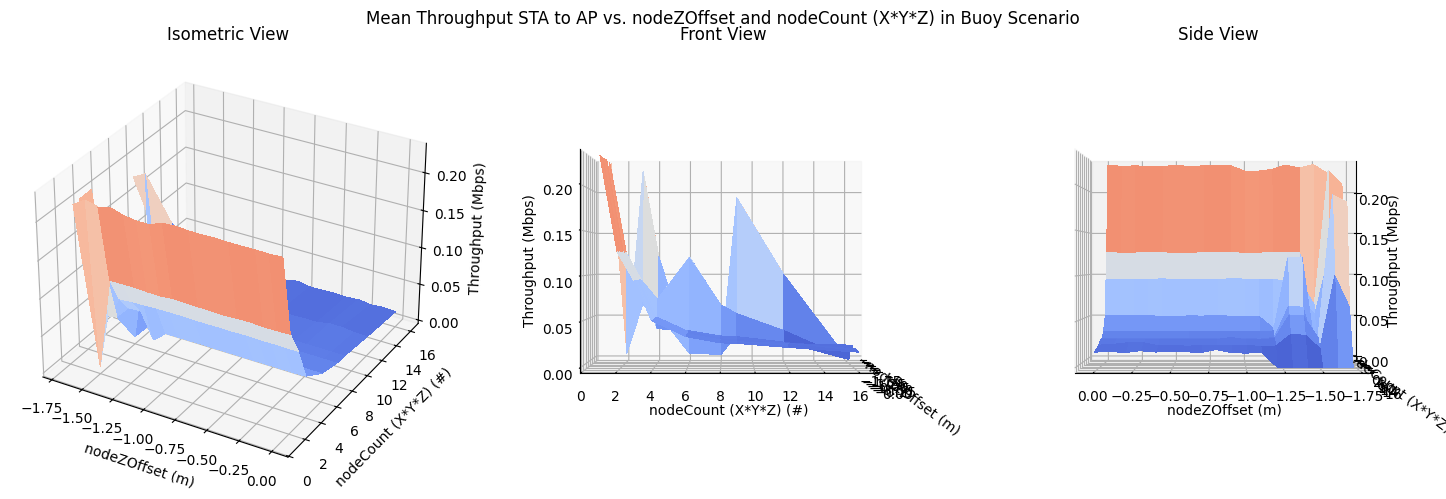

In [34]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean Throughput STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(packet_flow_stats['nodeZOffset'].unique())
y_unique = np.sort(packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'].unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (packet_flow_stats['nodeZOffset'] == node_z_offset) & \
               (packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = packet_flow_stats.loc[mask, 'Throughput'].mean()

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Throughput (Mbps)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Throughput (Mbps)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Throughput (Mbps)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()

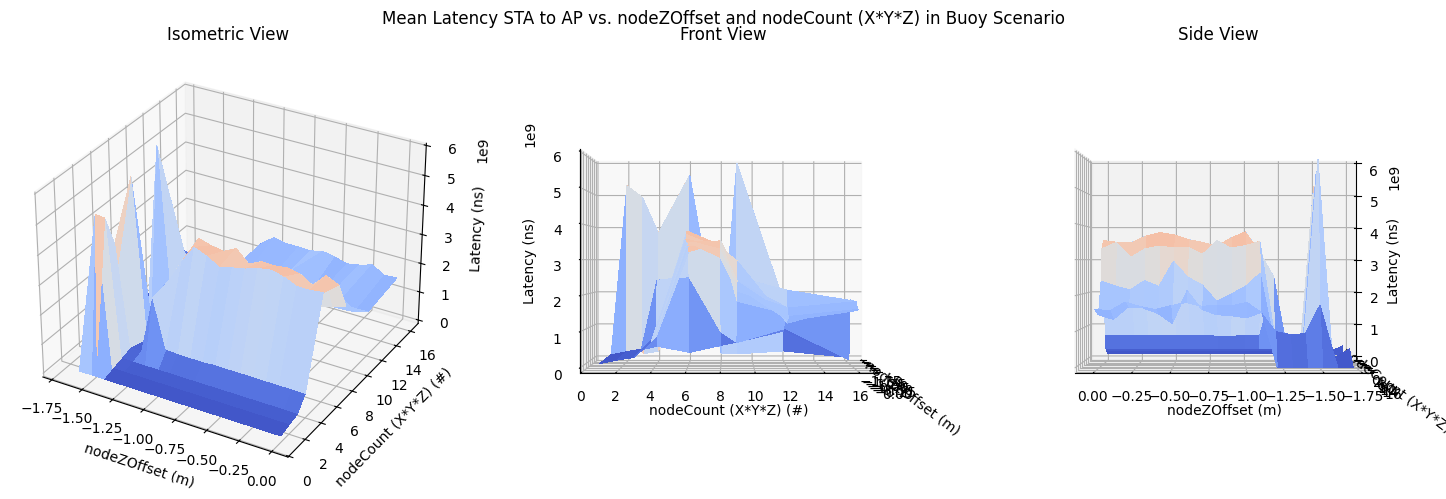

In [35]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean Latency STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(packet_flow_stats['nodeZOffset'].unique())
y_unique = np.sort(packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'].unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (packet_flow_stats['nodeZOffset'] == node_z_offset) & \
               (packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = packet_flow_stats.loc[mask, 'Latency'].mean()

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Latency (ns)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Latency (ns)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Latency (ns)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()

In [36]:
power_state_stats['TotalPower'] = power_state_stats['TotalEnergy'] / power_state_stats['stopTime'] # Convert to W

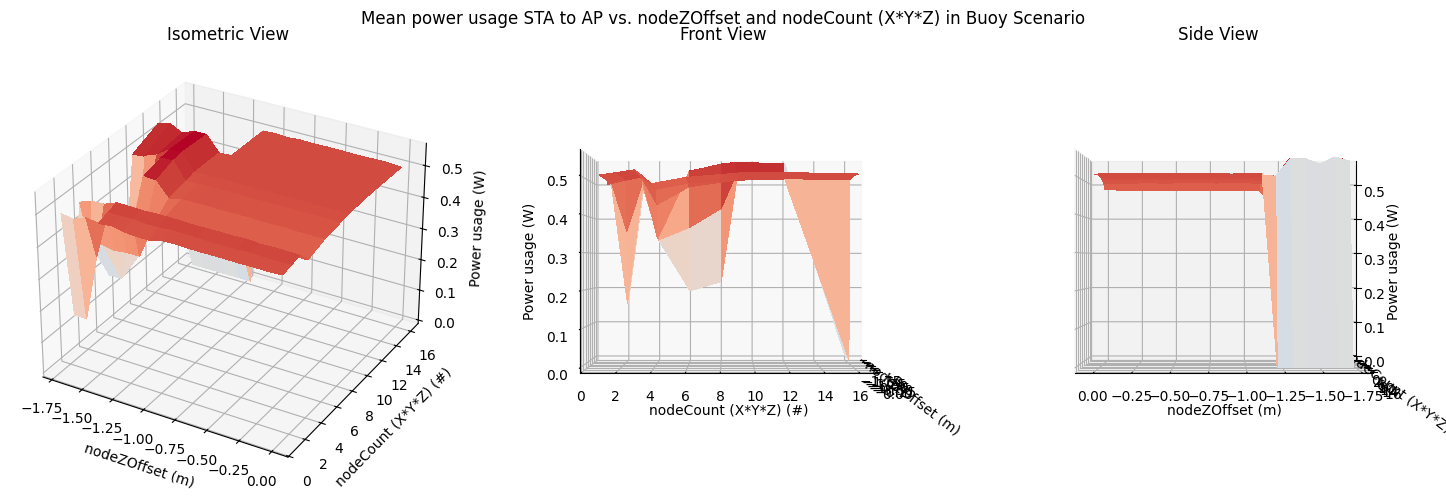

In [37]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean power usage STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(power_state_stats['nodeZOffset'].unique())
y_unique = np.sort(power_state_stats['nodeXCount'] * power_state_stats['nodeYCount'] * power_state_stats['nodeZCount'].unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (power_state_stats['nodeZOffset'] == node_z_offset) & \
               (power_state_stats['nodeXCount'] * power_state_stats['nodeYCount'] * power_state_stats['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = power_state_stats.loc[mask, 'TotalPower'].mean()

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Power usage (W)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Power usage (W)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Power usage (W)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()

In [38]:
# Merge the two dataframes on all config columns based on the last scenario folder's config
config_columns = list(sim_config.keys())
merged_stats = pd.merge(packet_flow_stats, power_state_stats, on=config_columns)

merged_stats["EnergyEfficiency"] = merged_stats["rxBytes"] * 8 / merged_stats["TotalEnergy"]

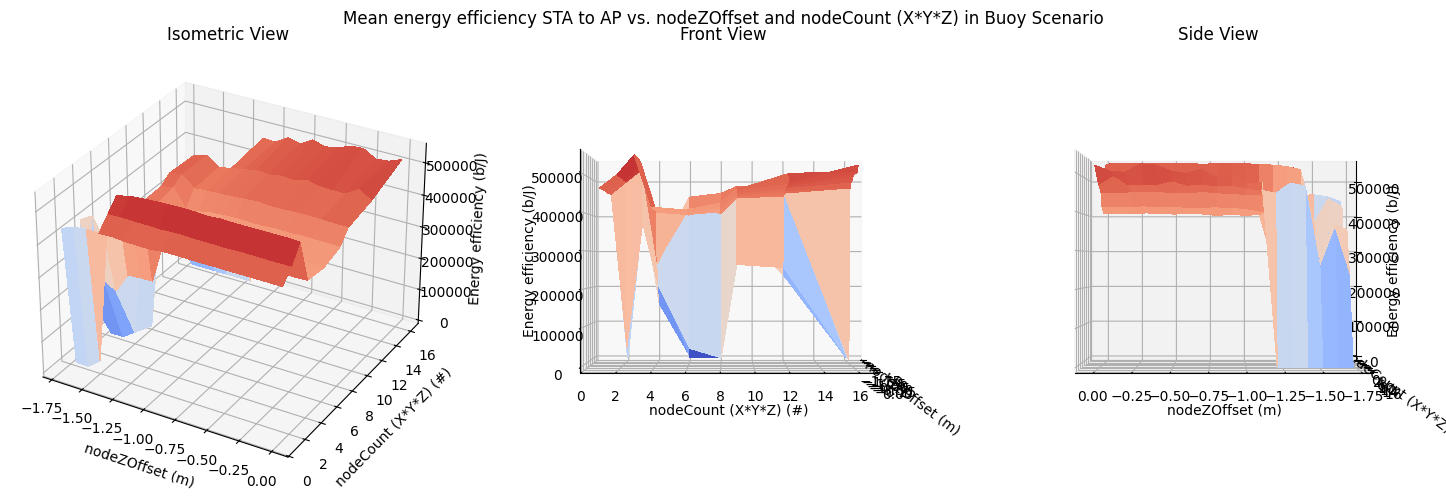

In [40]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean energy efficiency STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(merged_stats['nodeZOffset'].unique())
y_unique = np.sort(merged_stats['nodeXCount'] * merged_stats['nodeYCount'] * merged_stats['nodeZCount'].unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (merged_stats['nodeZOffset'] == node_z_offset) & \
               (merged_stats['nodeXCount'] * merged_stats['nodeYCount'] * merged_stats['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = merged_stats.loc[mask, 'EnergyEfficiency'].mean()

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Energy efficiency (b/J)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Energy efficiency (b/J)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Energy efficiency (b/J)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()